# 🌳 Hierarchical Clustering: A Step-by-Step Exercise

Welcome to this interactive exercise! In this notebook, we will walk through the mathematical intuition and coding steps required to perform **Agglomerative Hierarchical Clustering**.

Agglomerative clustering uses a **"bottom-up"** approach:
1. Start by treating each individual data point as its own cluster.
2. Find the two closest clusters and merge them into a single cluster.
3. Repeat step 2 until all points are merged into a single massive cluster.
4. Visualize the merging history using a **Dendrogram**.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Set a clean plotting style
plt.style.use('seaborn-v0_8-whitegrid')

## Step 1: Create Mock 2D Data
To understand the math, we will use a very small dataset containing 5 points in a 2D space. 
Notice how points A and B are close to each other, while C, D, and E form a separate group further away.

,X1,X2
A,2.0,2.0
B,3.0,2.0
C,10.0,10.0
D,11.0,10.0
E,10.0,12.0


C:\Users\Sujeet\AppData\Local\Temp\ipykernel_21176\3399737750.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(label, (df['X1'][i] + 0.3, df['X2'][i]), fontsize=12, fontweight='bold')


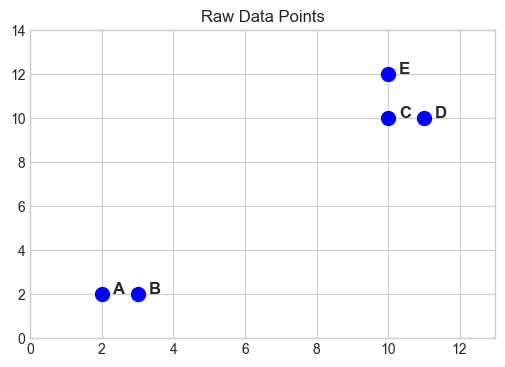

In [2]:
# Define 5 points (X, Y coordinates)
data = np.array([
    [2.0, 2.0],  # Point A
    [3.0, 2.0],  # Point B
    [10.0, 10.0], # Point C
    [11.0, 10.0], # Point D
    [10.0, 12.0]  # Point E
])

labels = ['A', 'B', 'C', 'D', 'E']
df = pd.DataFrame(data, columns=['X1', 'X2'], index=labels)
display(df)

# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(df['X1'], df['X2'], color='blue', s=100)

# Annotate the points
for i, label in enumerate(labels):
    plt.annotate(label, (df['X1'][i] + 0.3, df['X2'][i]), fontsize=12, fontweight='bold')

plt.title('Raw Data Points')
plt.xlim(0, 13)
plt.ylim(0, 14)
plt.show()

## Step 2: Calculate the Distance Matrix
Before we can cluster anything, the algorithm needs to know the exact distance between every single pair of points. 
We will compute the **Euclidean distance** (straight-line distance). Notice that the diagonal is 0 (the distance from a point to itself).

In [3]:
# pdist calculates the pairwise distances between observations
distances = pdist(df.values, metric='euclidean')

# squareform converts the flat array of distances into a symmetric 2D matrix
dist_matrix = squareform(distances)

# Put it in a DataFrame for readability
dist_df = pd.DataFrame(dist_matrix, columns=labels, index=labels)
print("Euclidean Distance Matrix:\n")
display(dist_df.round(2))

Euclidean Distance Matrix:



,A,B,C,D,E
A,0.00,1.00,11.31,12.04,12.81
B,1.00,0.00,10.63,11.31,12.21
C,11.31,10.63,0.00,1.00,2.00
D,12.04,11.31,1.00,0.00,2.24
E,12.81,12.21,2.00,2.24,0.00


### 🧠 Exercise Checkpoint
Look at the table above. Which two points have the smallest distance between them? 
*(Hint: You should see that A and B, as well as C and D, are very close. The algorithm will merge these first!)*

## Step 3: Compute the Linkage Matrix
Now we group the points together. We need to decide a **Linkage Criterion**—the rule that determines the distance between a newly formed cluster and other points.
- **Single Linkage:** Distance between two clusters is the distance between their *closest* points.
- **Complete Linkage:** Distance between their *furthest* points.
- **Ward's Method:** Merges clusters to minimize the overall variance.

Let's use **Single Linkage**.

In [4]:
# Perform hierarchical clustering using the single linkage method
Z = linkage(distances, method='single')

# Let's view the mathematical output of this linkage (the linkage matrix)
linkage_df = pd.DataFrame(Z, 
             columns=['Cluster 1', 'Cluster 2', 'Distance', 'Original Points in Cluster'],
             index=['Step 1', 'Step 2', 'Step 3', 'Step 4'])

display(linkage_df.round(2))

,Cluster 1,Cluster 2,Distance,Original Points in Cluster
Step 1,0.0,1.0,1.00,2.0
Step 2,2.0,3.0,1.00,2.0
Step 3,4.0,6.0,2.00,3.0
Step 4,5.0,7.0,10.63,5.0


**How to read the Linkage Matrix:**
- In **Step 1**, the algorithm merged point 0 (A) and point 1 (B) because their distance was 1.0. This new cluster now has 2 points.
- In **Step 2**, it merged point 2 (C) and point 3 (D) at a distance of 1.0. This cluster has 2 points.
- In **Step 3**, it merged point 4 (E) with the newly created cluster from Step 2 (identified mathematically as cluster #6). 
- Finally, it merged everything into one giant cluster.

## Step 4: Depicting the Dendrogram
The matrix above is hard to read. That is why we use a **Dendrogram**, a tree-like diagram that records the sequences of merges.
- The **x-axis** contains our data points.
- The **y-axis** represents the distance at which the clusters were merged.

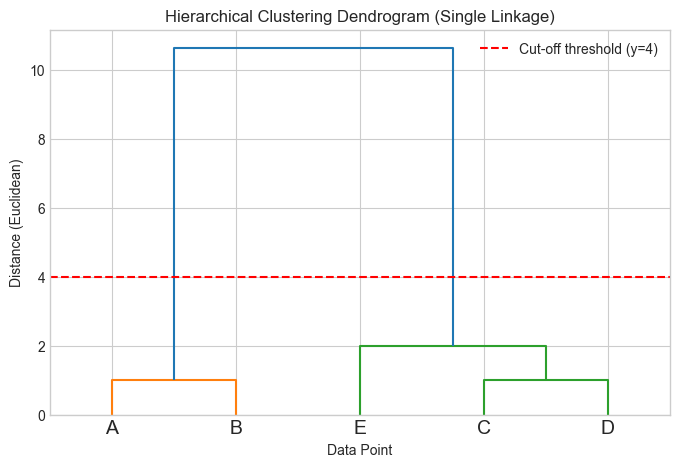

In [5]:
plt.figure(figsize=(8, 5))
plt.title('Hierarchical Clustering Dendrogram (Single Linkage)')
plt.xlabel('Data Point')
plt.ylabel('Distance (Euclidean)')

# Create the dendrogram
dendrogram(
    Z,
    labels=labels,
    leaf_rotation=0.,  # rotates the x axis labels
    leaf_font_size=14.,  # font size for the x axis labels
)

# Draw a horizontal cut-off line to form clusters
plt.axhline(y=4, color='r', linestyle='--', label='Cut-off threshold (y=4)')
plt.legend()
plt.show()

## Step 5: Extracting the Final Clusters
By drawing a horizontal line across the dendrogram at a specific distance threshold (like `y=4` in the red dashed line above), we "cut the tree". 
Any vertical lines intersected by our cut become our final separate clusters.

Final Cluster Assignments:



,X1,X2,Cluster
A,2.0,2.0,1
B,3.0,2.0,1
C,10.0,10.0,2
D,11.0,10.0,2
E,10.0,12.0,2


C:\Users\Sujeet\AppData\Local\Temp\ipykernel_21176\1475290782.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(label, (df['X1'][i] + 0.3, df['X2'][i]), fontsize=12)


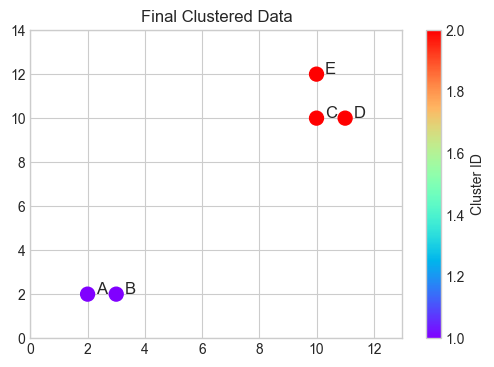

In [7]:
# Form flat clusters from the hierarchical clustering defined by the given linkage matrix Z.
# We will use a max distance (t) of 4.0 as our cut-off.
max_dist = 4.0
cluster_assignments = fcluster(Z, t=max_dist, criterion='distance')

df['Cluster'] = cluster_assignments
print("Final Cluster Assignments:\n")
display(df)

# Plot the final results!
plt.figure(figsize=(6, 4))
scatter = plt.scatter(df['X1'], df['X2'], c=df['Cluster'], cmap='rainbow', s=100)

for i, label in enumerate(labels):
    plt.annotate(label, (df['X1'][i] + 0.3, df['X2'][i]), fontsize=12)

plt.title('Final Clustered Data')
plt.xlim(0, 13)
plt.ylim(0, 14)
plt.colorbar(scatter, label='Cluster ID')
plt.show()

### 🎉 Conclusion
Congratulations! You have successfully stepped through the entire Hierarchical Clustering pipeline:
1. **Distance** -> 2. **Linkage** -> 3. **Dendrogram** -> 4. **Thresholding (Cutting)**.

*Bonus Exercise:* Try changing the linkage method in Step 3 from `'single'` to `'complete'` or `'ward'` and rerun the cells to see how the Dendrogram shape changes!